# Module 1 · Can I trust this average?

**Module 1 of the spiral — the drill-down question starts here:** before we compare partner B vs A in a slice, can we even trust the *average* of a metric like EPV/EPC? This module profiles the shape (skew, zeros, whales). *Runs on the synthetic teaching dataset; the real `online_banking` data behaves the same way.*

# Module 2 — Look Before You Leap: Outliers, Skewness & Transformations
### Practical Statistics for Analysts @ Natural Intelligence

EPV is the most important number at NI — and the most **dangerous to average naively**.
Most visits earn **\$0**; a handful of conversions (a mortgage lead!) earn hundreds.
That shape — a spike at zero plus a long right tail — means **the mean is unstable**
and a single "whale" can swing your daily report.

This module: see the shape, find the outliers, fix it responsibly.

In [1]:
import sys
from pathlib import Path
_here = Path.cwd()
for _c in [_here, *_here.parents]:
    if (_c / "src" / "ni_style.py").exists():
        sys.path.insert(0, str(_c / "src")); break
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import ni_style as ni
ni.set_style()

visits = ni.load_visits()
print(f"Loaded {len(visits):,} visits | {visits['date'].min().date()} -> {visits['date'].max().date()}")
visits.head()

Loaded 180,000 visits | 2026-03-01 -> 2026-05-30


,visit_id,date,day_of_week,is_weekend,engine,device,vertical,converted,revenue,cost,profit
0,1,2026-03-01,Sun,True,Bing,mobile,vpn,0,0.0000,0.8094,-0.8094
1,2,2026-03-01,Sun,True,Organic,tablet,vpn,0,0.0000,0.1886,-0.1886
2,3,2026-03-01,Sun,True,Google,tablet,web_builders,0,0.0000,3.6039,-3.6039
3,4,2026-03-01,Sun,True,Google,desktop,dating,1,10.0945,1.0836,9.0109
4,5,2026-03-01,Sun,True,Google,desktop,streaming,1,5.6453,0.8228,4.8225


## 1. The mean lies — see the shape first

Three views of the same revenue data: all visits (the zero spike), converting
visits only (the long tail), and the log-transform that tames it.

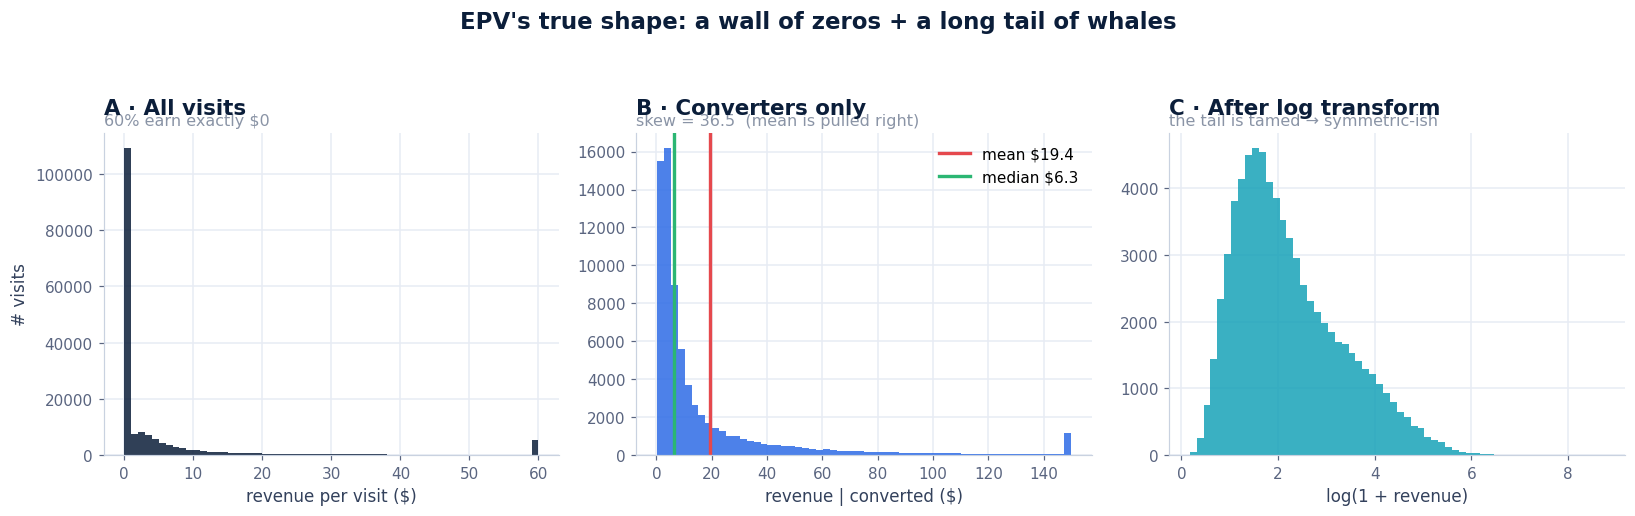

Top 1% of converters earn 17% of ALL revenue.


In [2]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))

# A — all visits: the zero spike dominates
ax[0].hist(visits["revenue"].clip(upper=60), bins=60, color=ni.NAVY, alpha=0.85)
ax[0].set_xlabel("revenue per visit ($)"); ax[0].set_ylabel("# visits")
ni.titlebox(ax[0], "A · All visits", f"{(visits.revenue==0).mean():.0%} earn exactly $0")

# B — converting visits only: heavy right tail, mean >> median
rev = visits.loc[visits.converted == 1, "revenue"]
ax[1].hist(rev.clip(upper=150), bins=60, color=ni.BLUE, alpha=0.85)
ax[1].axvline(rev.mean(), color=ni.RED, lw=2.2, label=f"mean ${rev.mean():.1f}")
ax[1].axvline(rev.median(), color=ni.GREEN, lw=2.2, label=f"median ${rev.median():.1f}")
ax[1].set_xlabel("revenue | converted ($)"); ax[1].legend()
ni.titlebox(ax[1], "B · Converters only", f"skew = {stats.skew(rev):.1f}  (mean is pulled right)")

# C — log1p transform: roughly symmetric, analyzable
ax[2].hist(np.log1p(rev), bins=60, color=ni.TEAL, alpha=0.85)
ax[2].set_xlabel("log(1 + revenue)")
ni.titlebox(ax[2], "C · After log transform", "the tail is tamed → symmetric-ish")

fig.suptitle("EPV's true shape: a wall of zeros + a long tail of whales",
             fontsize=15, fontweight="bold", color=ni.NAVY, y=1.06)
fig.tight_layout(); ni.savefig(fig, "m2_distributions"); plt.show()

print(f"Top 1% of converters earn {rev[rev>=rev.quantile(.99)].sum()/rev.sum():.0%} of ALL revenue.")

## 2. Daily EPV is mostly noise — a whale is just the clearest culprit

At ~2,000 visits/day, EPV swings violently from day to day. It is tempting to read a daily spike as
a "trend" and react — but at this resolution the number is dominated by **noise** (with the
occasional whale on top). Two things make this graph honest, and they correct a common misreading:
1. a **7-day rolling mean** shows the *real* signal hiding under the daily noise, and
2. removing each day's single biggest whale **barely calms the line** — proof the problem is
   pervasive small-n noise, not one deletable outlier.

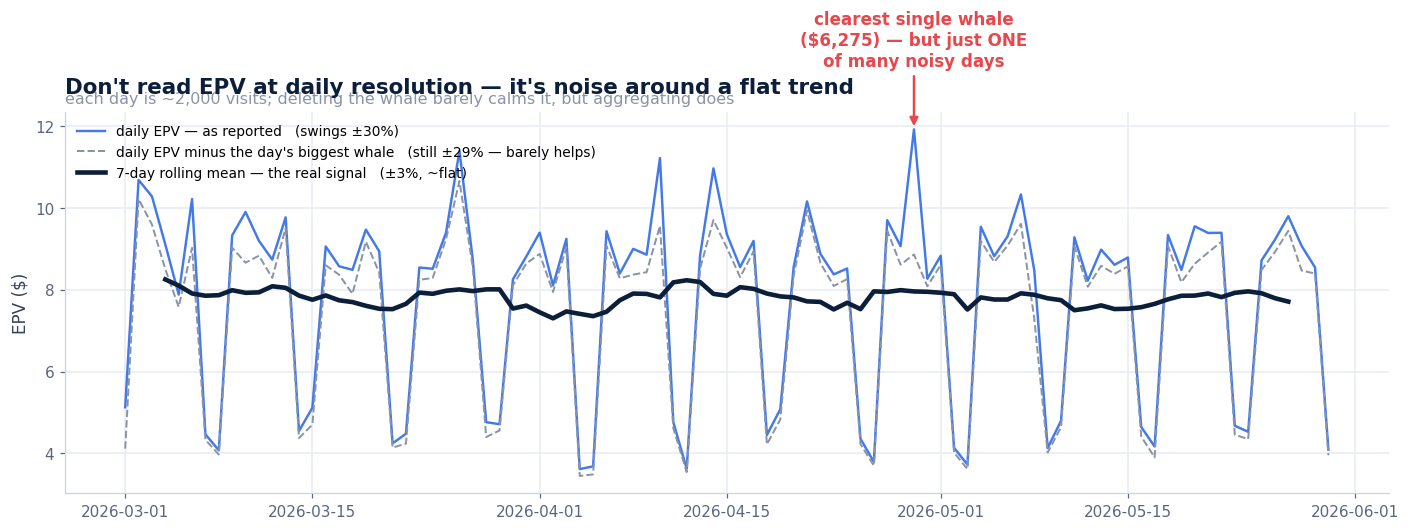

day-to-day variation (CV):  raw 30%   |   minus biggest whale 29%   |   7-day rolling 3%
Removing the single biggest whale leaves ~98% of the swing → the noise is pervasive, not one whale.


In [3]:
daily = visits.groupby("date", observed=True).agg(
    revenue=("revenue", "sum"), visits=("visit_id", "size"), biggest=("revenue", "max")).reset_index()
daily["EPV"] = daily.revenue / daily.visits

# (a) daily EPV with each day's single biggest conversion removed
daily["EPV_ex_whale"] = (daily.revenue - daily.biggest) / (daily.visits - 1)
# (b) the 7-day rolling mean = the stable underlying signal (aggregation beats deletion)
daily["EPV_roll7"] = daily["EPV"].rolling(7, center=True).mean()

def cv(x):                                   # day-to-day variation = std / mean
    x = x.dropna(); return x.std() / x.mean()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(daily.date, daily.EPV, color=ni.BLUE, lw=1.6, alpha=0.9,
        label=f"daily EPV — as reported   (swings ±{cv(daily.EPV):.0%})")
ax.plot(daily.date, daily.EPV_ex_whale, color=ni.GREY, lw=1.3, ls="--",
        label=f"daily EPV minus the day's biggest whale   (still ±{cv(daily.EPV_ex_whale):.0%} — barely helps)")
ax.plot(daily.date, daily.EPV_roll7, color=ni.NAVY, lw=3,
        label=f"7-day rolling mean — the real signal   (±{cv(daily.EPV_roll7):.0%}, ~flat)")
spike = daily.loc[daily.EPV.idxmax()]
ax.annotate(f"clearest single whale\n(${spike.biggest:,.0f}) — but just ONE\nof many noisy days",
            xy=(spike.date, spike.EPV), xytext=(spike.date, spike.EPV * 1.13),
            ha="center", color=ni.RED, fontweight="bold",
            arrowprops=dict(arrowstyle="-|>", color=ni.RED, lw=1.6))
ax.set_ylabel("EPV ($)"); ax.legend(loc="upper left", fontsize=9)
ni.titlebox(ax, "Don't read EPV at daily resolution — it's noise around a flat trend",
            "each day is ~2,000 visits; deleting the whale barely calms it, but aggregating does")
fig.tight_layout(); ni.savefig(fig, "m2_whale_timeseries"); plt.show()

print(f"day-to-day variation (CV):  raw {cv(daily.EPV):.0%}   |   minus biggest whale "
      f"{cv(daily.EPV_ex_whale):.0%}   |   7-day rolling {cv(daily.EPV_roll7):.0%}")
print("Removing the single biggest whale leaves ~98% of the swing → the noise is pervasive, not one whale.")

> **So which spikes do we ignore? All of them.** The marked day is just the one where a *single*
> conversion is the obvious culprit — but the de-whaled line proves the rest of the line is *equally*
> erratic for diffuse reasons (small n + multiple whales + day-of-week mix). This is Module 1's wide
> daily sampling distribution in time-series form. The rule isn't "ignore that one peak" — it's
> **never act on a single day's EPV; read the 7-day trend, or test the difference properly.**

## 3. Finding outliers: visual + rule-based

Boxplots on a **log scale** reveal the whales by vertical; the IQR and z-score
rules flag them numerically. (Note: with skewed data the IQR rule is more
trustworthy than the z-score, which is itself distorted by the outliers.)

/tmp/ipykernel_93314/2041650096.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, vert=True, patch_artist=True, labels=order, showfliers=True,


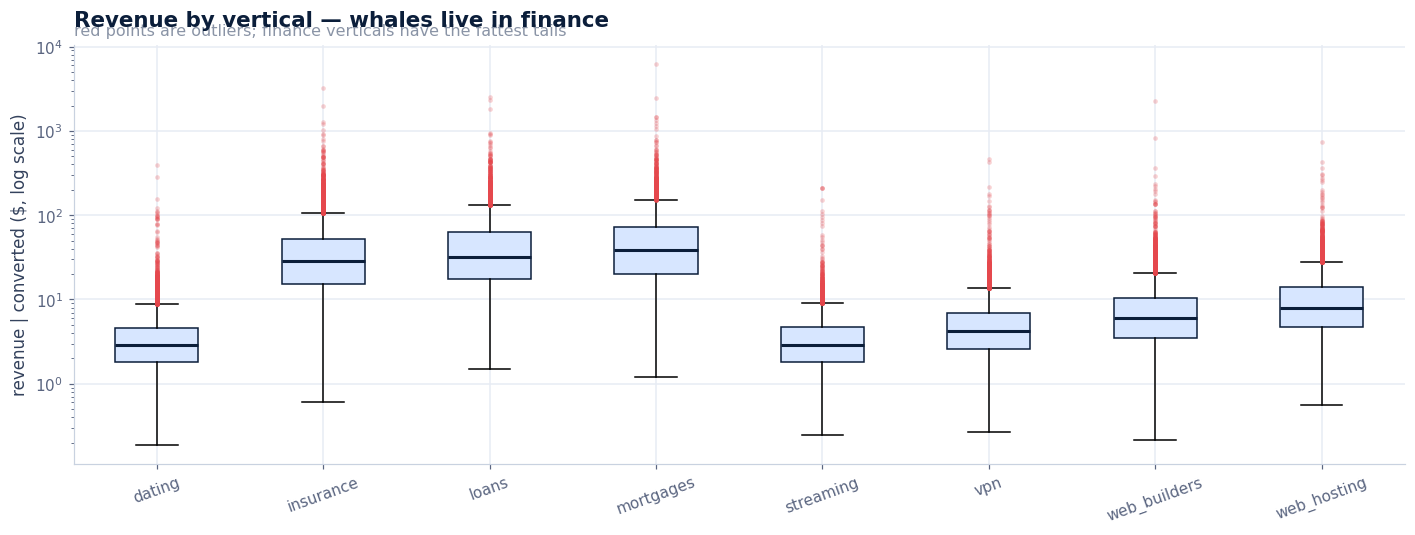

Converting visits flagged as high outliers:  IQR rule = 8,987   |   z>3 rule = 785
→ The IQR rule catches the heavy tail; the z-score under-flags because the whales inflate the SD.


In [16]:
fig, ax = plt.subplots(figsize=(13, 5))
order = visits.groupby("vertical")["revenue"].median().sort_values().index.tolist()
data = [visits.loc[(visits.vertical==v) & (visits.converted==1), "revenue"].values for v in order]
bp = ax.boxplot(data, vert=True, patch_artist=True, labels=order, showfliers=True,
                flierprops=dict(marker="o", markersize=3, alpha=0.25, markerfacecolor=ni.RED, markeredgecolor="none"))
for patch in bp["boxes"]:
    patch.set(facecolor=ni.LIGHT, edgecolor=ni.NAVY)
for med in bp["medians"]:
    med.set(color=ni.NAVY, linewidth=2)
ax.set_yscale("log"); ax.set_ylabel("revenue | converted ($, log scale)")
plt.setp(ax.get_xticklabels(), rotation=20)
ni.titlebox(ax, "Revenue by vertical — whales live in finance",
            "red points are outliers; finance verticals have the fattest tails")
fig.tight_layout(); ni.savefig(fig, "m2_outliers_box"); plt.show()

# Rule-based counts
def outlier_counts(x):
    q1, q3 = np.percentile(x, [25, 75]); iqr = q3 - q1
    iqr_out = (x > q3 + 1.5*iqr).sum()
    z = (x - x.mean())/x.std(); z_out = (np.abs(z) > 3).sum()
    return iqr_out, z_out
io, zo = outlier_counts(rev.values)
print(f"Converting visits flagged as high outliers:  IQR rule = {io:,}   |   z>3 rule = {zo:,}")
print("→ The IQR rule catches the heavy tail; the z-score under-flags because the whales inflate the SD.")

## 4. Does the choice of summary change the decision?

Mean vs median vs 5%-trimmed mean by device — notice the **median and trimmed
mean are far more stable**, and they still preserve the mobile-vs-desktop gap
we care about (without being hostage to whales).

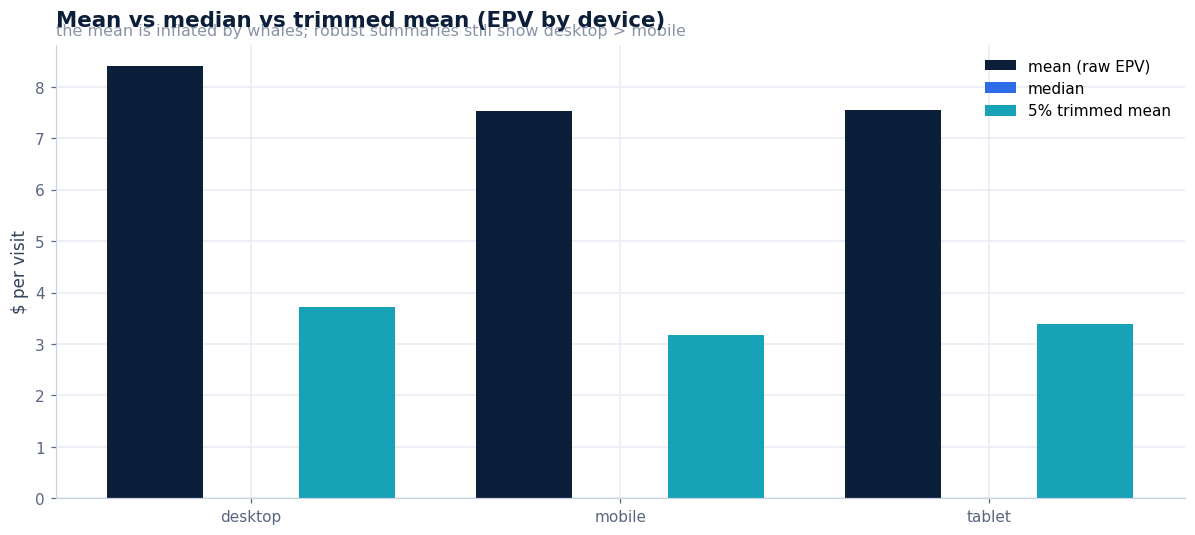

,mean (raw EPV),median,5% trimmed mean
device,,,
desktop,8.40,0.0,3.71
mobile,7.53,0.0,3.18
tablet,7.55,0.0,3.39


In [5]:
def trimmed_mean(x, p=0.05): return stats.trim_mean(x, p)
g = visits.groupby("device", observed=True)["revenue"]
summ = pd.DataFrame({
    "mean (raw EPV)": g.mean(),
    "median": g.median(),
    "5% trimmed mean": g.apply(lambda s: trimmed_mean(s.values)),
}).reindex(["desktop","mobile","tablet"])

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(summ)); w = 0.26
for i, col in enumerate(summ.columns):
    ax.bar(x + (i-1)*w, summ[col], w, label=col, color=[ni.NAVY, ni.BLUE, ni.TEAL][i])
ax.set_xticks(x); ax.set_xticklabels(summ.index); ax.set_ylabel("$ per visit")
ax.legend()
ni.titlebox(ax, "Mean vs median vs trimmed mean (EPV by device)",
            "the mean is inflated by whales; robust summaries still show desktop > mobile")
fig.tight_layout(); ni.savefig(fig, "m2_robust_summaries"); plt.show()
display(summ.round(2))

### ✅ Takeaway

> **Always plot the distribution before you quote an average.**
> For EPV at NI: report the **mean** (it's what the business banks) **but** sanity-check
> with the **median**, flag outliers with the **IQR rule**, and consider a
> **log transform** or **bootstrap** for any test. A spike in mean EPV is a *whale
> question* before it's a *trend question*.

**Next:** now that we respect EPV's shape, can we trust a *relationship* —
like "EPV depends on the day of week"? → *Module 3.*

**→ The skill that automates this:** `/profile-data`. Next: **Module 2 — how much data is really here?** (i.i.d. / effective-n).